# 3장 실습 — 간극을 숫자로 재는 법

이 노트북이 이 책의 첫 이정표다. 앞으로 나올 모든 기법 — 시스템 식별, 잔차 모델, 도메인 랜덤화, 합성 데이터 — 은 마지막에 같은 질문을 받는다. **그래서 간극이 얼마나 줄었나.** 그 질문에 답할 자를 여기서 만든다.

문제는 이렇다. 시뮬레이터에서 정책 여럿을 평가했다. 이 순위가 실기에서도 그대로일까? 그걸 어떻게 재는가?

실기 로봇 없이 이 질문을 다루기 위해, 이 노트북은 **같은 물리 엔진을 파라미터만 다르게 두 번 세운다.** 하나를 「실기」라 부르고 다른 하나를 「시뮬」이라 부른다. 진짜 로봇이 아니라는 점은 분명하다. 대신 **참값을 안다**는 이점이 생긴다. 실기의 마찰이 얼마인지 알기 때문에 「이 지표가 제대로 작동하는가」를 검증할 수 있다. 진짜 하드웨어로는 못 하는 일이다.

실행 시간은 CPU에서 2~3분이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import unicodedata
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    # 화면에서 차지하는 칸 수. 한글은 한 글자가 두 칸이다
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    # 파이썬의 f"{s:<12}" 는 글자 수로 세어 한글 표를 어긋나게 한다
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__)

mujoco 3.13.0


## 같은 엔진, 다른 파라미터

과제는 평면 밀기다. 원통형 밀대가 원반을 밀어 목표 원 안에 넣는다. 20Hz로 속도를 명령하고 7초 안에 끝내야 한다.

모델에서 바뀌는 것은 둘뿐이다. **마찰계수**와 **액추에이터 게인**이다. 그리고 모델 밖에서 둘을 더 건다 — **관측 잡음**과 **제어 지연**이다. 이 넷이 이 노트북에서 다룰 간극의 전부다. 실제 sim2real 간극은 훨씬 복잡하지만, 넷만 있어도 이 장이 말하려는 것은 다 나온다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom name="block" type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom name="pusher" type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

CTRL_HZ = 20       # 정책이 명령을 내는 주기
EP_STEPS = 140     # 한 판의 제어 스텝 수 (7초)
GOAL_R = .04       # 이 반경 안에 들어오면 성공
STANDOFF = .045    # 원반 뒤 접점까지의 거리
STOP = .015        # 이만큼 가까우면 손을 뗀다


def make(mu, kv):
    m = mujoco.MjModel.from_xml_string(XML.format(mu=mu, kv=kv))
    return m, mujoco.MjData(m)


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def reset(m, d, rng):
    mujoco.mj_resetData(m, d)
    bx, by = rng.uniform(-.03, .03, 2)
    d.qpos[0:2] = [bx, by]
    d.qpos[2] = .031
    d.qpos[7:9] = [bx - .09, by]     # 밀대는 원반 뒤에서 시작한다
    mujoco.mj_forward(m, d)
    return np.array([.28, 0.]) + rng.uniform(-.04, .04, 2)

## 여섯 정책

정책 여섯 개를 손으로 짠다. 학습한 정책이 아니라 규칙 기반인 것이 중요하다. 학습을 끼우면 시드마다 결과가 흔들려 지표의 성질이 가려진다. 2권 5장에서 액션 헤드를 비교할 때 지각을 고정했던 것과 같은 이유다 — **재려는 것만 남기고 나머지는 고정한다.**

여섯이 각각 다른 것에 취약하도록 설계했다.

| 정책 | 전략 | 무엇에 취약한가 |
|---|---|---|
| 직진 | 목표 방향으로 꾸준히 민다 | (기준선) |
| 살살 | 아주 천천히 민다 | 시간 제한 |
| 밀고 물러나기 | 짧게 밀고 물러나기를 되풀이 | (기준선) |
| 돌진-코스트 | 세게 밀고 일찍 손을 뗀다 | **마찰** — 미끄러지는 거리에 건다 |
| 빠른 서보 | 높은 이득으로 오차를 쫓는다 | **지연** — 늦게 오면 진동한다 |
| 정밀 정렬 | 목표 가까이에서 미세 보정 | **관측 잡음** — 헛것을 쫓는다 |

In [4]:
def _behind(b, g, standoff=STANDOFF):
    # 원반 뒤 접점 — 목표의 반대쪽이다
    return b - unit(g - b) * standoff


def mk_push(speed, release=0., period=0):
    def pol(b, p, g, t, st):
        rem = np.linalg.norm(g - b)
        if rem < max(release, STOP):
            return np.zeros(2)
        if period and t % period >= period - 6:
            return -unit(g - b) * speed * .5
        c = _behind(b, g)
        if np.linalg.norm(p - c) > .012:
            return unit(c - p) * max(speed, .3)
        return unit(g - b) * speed
    return pol


def mk_servo(K, speed):
    def pol(b, p, g, t, st):
        if np.linalg.norm(g - b) < STOP:
            return np.zeros(2)
        e = _behind(b, g) - p
        near = np.linalg.norm(e) < .015
        v = K * e + unit(g - b) * speed * near
        return np.clip(v, -1.2, 1.2)
    return pol


def mk_fine(speed, tol):
    def pol(b, p, g, t, st):
        rem = np.linalg.norm(g - b)
        if rem < tol:
            return np.zeros(2)
        c = _behind(b, g)
        if np.linalg.norm(p - c) > .010:
            return unit(c - p) * .30
        return unit(g - b) * (speed if rem > .06 else speed * .35)
    return pol


POLICIES = {
    "직진":         mk_push(.25),
    "살살":         mk_push(.12),
    "밀고 물러나기": mk_push(.30, period=22),
    "돌진-코스트":   mk_push(.60, release=.11),
    "빠른 서보":     mk_servo(14., .25),
    "정밀 정렬":     mk_fine(.25, .006),
}
NAMES = list(POLICIES)
print(len(NAMES), "개 정책:", ", ".join(NAMES))

6 개 정책: 직진, 살살, 밀고 물러나기, 돌진-코스트, 빠른 서보, 정밀 정렬


In [5]:
def rollout(m, d, rng, pol, obs_noise=0., lat=0):
    # 한 판을 끝까지 굴리고 성공 여부를 돌려준다
    goal = reset(m, d, rng)
    st = {}
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    buf = [np.zeros(2)] * (lat + 1)
    for t in range(EP_STEPS):
        b = d.qpos[0:2]
        if obs_noise:
            b = b + rng.normal(0, obs_noise, 2)
        buf.append(pol(np.asarray(b), np.asarray(d.qpos[7:9]),
                       goal, t, st))
        d.ctrl[:] = buf[-1 - lat]      # 지연: 옛 명령을 쓴다
        for _ in range(sub):
            mujoco.mj_step(m, d)
    return np.linalg.norm(d.qpos[0:2] - goal) < GOAL_R


def run(mu, kv, obs_noise=0., lat=0, n=150, seed0=0):
    # 정책마다 n판을 돌린다. 시드를 정책끼리 공유하므로
    # 여섯이 같은 초기 조건에서 겨루게 된다
    m, d = make(mu, kv)
    out = {}
    for name, pol in POLICIES.items():
        out[name] = np.array([
            rollout(m, d, np.random.default_rng(seed0 + i), pol,
                    obs_noise, lat)
            for i in range(n)], dtype=bool)
    return out

## 실기를 정한다

「실기」는 마찰 0.6, 게인 120, 관측 잡음 4mm, 제어 지연 2스텝(100ms)으로 둔다. 로봇을 쓴다면 이 값들을 모르는 채로 시작하겠지만, 여기서는 안다. 그게 이 노트북의 이점이다.

성공률과 함께 **Wilson 신뢰구간**을 낸다. 2권 14장에서 쓴 그것이다. 성공률 하나만 보면 150판에서 0.80과 0.75가 다른 값처럼 보이지만 구간은 겹친다.

In [6]:
def wilson(k, n, z=1.96):
    # 이항 비율의 Wilson 신뢰구간
    if n == 0:
        return 0., 1.
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return mid - half, mid + half


N = 150
REAL_CFG = dict(mu=.60, kv=120., obs_noise=.004, lat=2)

real = run(**REAL_CFG, n=N, seed0=0)
print(pad("정책", 16) + pad("성공률", 9, True)
      + pad("95% Wilson 구간", 22, True))
for k in NAMES:
    lo, hi = wilson(real[k].sum(), N)
    span = f"[{lo:.3f}, {hi:.3f}]"
    print(pad(k, 16) + pad(f"{real[k].mean():.3f}", 9, True)
          + pad(span, 22, True))

정책               성공률       95% Wilson 구간
직진                0.693        [0.615, 0.762]
살살                0.327        [0.257, 0.405]
밀고 물러나기       0.507        [0.427, 0.586]
돌진-코스트         0.060        [0.032, 0.110]
빠른 서보           0.033        [0.014, 0.076]
정밀 정렬           0.673        [0.595, 0.743]


## 시뮬 후보 넷

이제 시뮬레이터를 세운다. 실기 파라미터를 모른다고 치고, 흔히 하는 순서대로 네 단계를 밟는다.

| 이름 | 무엇을 맞췄나 |
|---|---|
| S0 기본값 | 아무것도 안 맞췄다 |
| S1 마찰 | 마찰만 실기 값으로 |
| S2 마찰+게인 | 액추에이터 게인까지 |
| S3 +지연 | 제어 지연까지 |

S3에도 관측 잡음은 넣지 않는다. 잡음까지 넣으면 실기와 완전히 같아져 비교가 의미를 잃는다. 그 경우는 마지막 절에서 따로 다룬다.

In [7]:
SIMS = {
    "S0 기본값":    dict(mu=.20, kv=300.),
    "S1 마찰":      dict(mu=.60, kv=300.),
    "S2 마찰+게인": dict(mu=.60, kv=120.),
    "S3 +지연":     dict(mu=.60, kv=120., lat=2),
}
sims = {k: run(**v, n=N, seed0=0) for k, v in SIMS.items()}

print(pad("정책", 16) + pad("실기", 9, True)
      + "".join(pad(s, 14, True) for s in SIMS))
for k in NAMES:
    row = "".join(pad(f"{sims[s][k].mean():.3f}", 14, True)
                  for s in SIMS)
    print(pad(k, 16) + pad(f"{real[k].mean():.3f}", 9, True) + row)

정책                 실기     S0 기본값       S1 마찰  S2 마찰+게인      S3 +지연
직진                0.693         0.687         1.000         1.000         0.960
살살                0.327         1.000         1.000         1.000         0.027
밀고 물러나기       0.507         0.420         1.000         1.000         0.693
돌진-코스트         0.060         0.293         0.013         0.000         0.120
빠른 서보           0.033         0.973         1.000         1.000         0.080
정밀 정렬           0.673         1.000         1.000         1.000         0.853


## 지표 둘

**Pearson 상관계수 r** 은 시뮬 성공률과 실기 성공률이 직선 위에 얼마나 잘 놓이는지를 잰다. 익숙한 지표이고 계산도 쉽다.

문제는 r이 **순위**를 직접 보지 않는다는 점이다. 정책을 고르는 입장에서 정말 알고 싶은 것은 「시뮬에서 1등인 정책이 실기에서도 1등인가」다. 성공률이 조금씩 어긋나는 것은 견딜 수 있지만 순위가 뒤집히면 잘못된 정책을 고르게 된다.

그래서 SimplerEnv(Li et al., CoRL 2024)가 도입한 것이 **MMRV**(Mean Maximum Rank Violation)다. 이 노트북에서는 다음과 같이 구현한다.

정책 쌍 (i, j)에 대해, 시뮬이 매긴 대소 관계가 실기와 어긋났다면 그 위반의 크기를 **실기 쪽 성공률 차이**로 잰다.

> RV(i, j) = |실기 성공률 차이| × (시뮬과 실기의 대소 관계가 어긋났으면 1, 아니면 0)

그리고 각 정책이 겪은 가장 큰 위반을 모아 평균한다.

> MMRV = 정책마다 가장 큰 RV 를 고른 뒤 그것들의 평균

0이면 순위가 완전히 보존된 것이고, 값이 클수록 크게 어긋난 것이다. 위반의 크기를 **실기** 차이로 재는 것이 핵심이다. 실기에서 0.80짜리와 0.03짜리 정책의 순위를 뒤집는 것은 0.80과 0.79를 뒤집는 것보다 훨씬 큰 잘못이다.

In [8]:
def pearson(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    x, y = x - x.mean(), y - y.mean()
    den = np.sqrt((x * x).sum() * (y * y).sum())
    return float((x * y).sum() / den) if den > 1e-12 else np.nan


def mmrv(realr, simr):
    # Mean Maximum Rank Violation. 위반 크기는 실기 차이로 잰다
    r, s = np.asarray(realr, float), np.asarray(simr, float)
    n = len(r)
    worst = np.zeros(n)
    for i in range(n):
        v = 0.
        for j in range(n):
            if i == j:
                continue
            if np.sign(r[i] - r[j]) != np.sign(s[i] - s[j]):
                v = max(v, abs(r[i] - r[j]))
        worst[i] = v
    return float(worst.mean())


rv = np.array([real[k].mean() for k in NAMES])
scores = {}
print(pad("시뮬", 16) + pad("MMRV (낮을수록)", 18, True)
      + pad("Pearson r (높을수록)", 24, True))
for s, res in sims.items():
    sv = np.array([res[k].mean() for k in NAMES])
    scores[s] = (mmrv(rv, sv), pearson(rv, sv))
    print(pad(s, 16) + pad(f"{scores[s][0]:.3f}", 18, True)
          + pad(f"{scores[s][1]:.3f}", 24, True))

시뮬               MMRV (낮을수록)    Pearson r (높을수록)
S0 기본값                    0.422                   0.147
S1 마찰                      0.471                   0.541
S2 마찰+게인                 0.471                   0.541
S3 +지연                     0.142                   0.910


## 산점도로 보기

숫자만으로는 무엇이 어긋났는지 안 보인다. 가로축에 시뮬 성공률, 세로축에 실기 성공률을 놓고 정책을 찍는다. 대각선 위에 놓이면 시뮬이 실기를 그대로 맞춘 것이다.

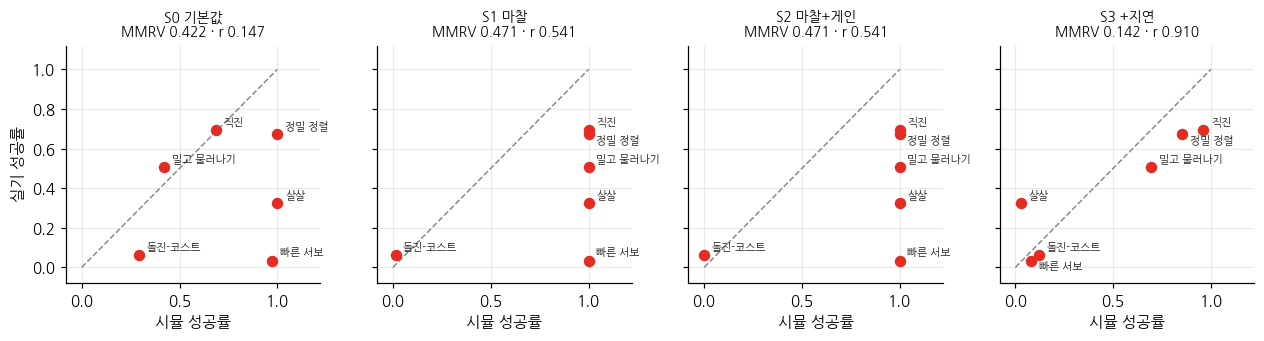

In [9]:
labels = list(SIMS)
fig, axes = plt.subplots(1, 4, figsize=(11.6, 3.2), sharey=True)
for ax, s in zip(axes, labels):
    sv = np.array([sims[s][k].mean() for k in NAMES])
    ax.plot([0, 1], [0, 1], "--", color=GREY, lw=1)
    ax.scatter(sv, rv, s=42, color=RED, zorder=3)
    done = []
    for k, x, y in zip(NAMES, sv, rv):
        # 가까이 붙은 점의 라벨은 아래로 쌓는다
        j = sum(1 for px, py in done
                if abs(px - x) < .22 and abs(py - y) < .10)
        done.append((x, y))
        ax.annotate(k, (x, y), fontsize=7, color=INK,
                    xytext=(5, 3 - 9 * j),
                    textcoords="offset points")
    m_, r_ = scores[s]
    ax.set_title(f"{s}\nMMRV {m_:.3f} · r {r_:.3f}", fontsize=9)
    ax.set_xlabel("시뮬 성공률")
    ax.set_xlim(-.08, 1.22)
    ax.set_ylim(-.08, 1.12)
axes[0].set_ylabel("실기 성공률")
plt.tight_layout()
plt.show()

## 어느 갭을 메우는 것이 순위를 되살리는가

위 표에서 읽을 것이 하나 있다. **마찰을 맞추는 것과 지연을 맞추는 것 중 무엇이 순위 예측에 더 크게 기여했는가.**

이 질문이 2부 전체의 방향을 정한다. 시뮬레이터를 실기에 맞추는 데 쓸 수 있는 시간은 유한하고, 어디에 쓸지 골라야 하기 때문이다.

한 가지 더 볼 것이 있다. **S1과 S2의 값이 같다.** 마찰을 맞춘 뒤에 게인까지 맞췄는데 지표가 한 자리도 움직이지 않았다. 왜 그런지는 앞의 성공률 표에 있다.

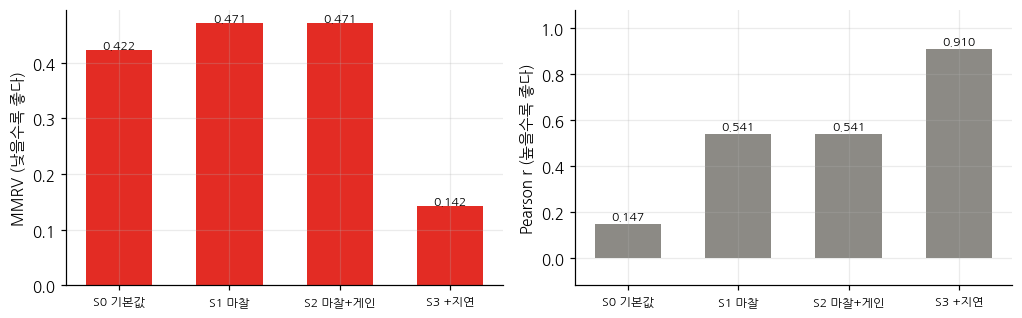

MMRV 가 가장 낮은 시뮬:      S3 +지연
Pearson r 이 가장 높은 시뮬: S3 +지연


In [10]:
mm = [scores[s][0] for s in labels]
pr = [scores[s][1] for s in labels]
x = np.arange(len(labels))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.0))
a1.bar(x, mm, color=RED, width=.6)
a1.set_ylabel("MMRV (낮을수록 좋다)")
for i, v in enumerate(mm):
    a1.text(i, v + .004, f"{v:.3f}", ha="center", fontsize=8)

a2.bar(x, pr, color=GREY, width=.6)
a2.set_ylabel("Pearson r (높을수록 좋다)")
a2.set_ylim(min(0, min(pr)) - .12, 1.08)
for i, v in enumerate(pr):
    a2.text(i, v + .02, f"{v:.3f}", ha="center", fontsize=8)

for a in (a1, a2):
    a.set_xticks(x)
    a.set_xticklabels(labels, fontsize=8)
plt.tight_layout()
plt.show()

best_m = labels[int(np.argmin(mm))]
best_r = labels[int(np.argmax(pr))]
print(f"MMRV 가 가장 낮은 시뮬:      {best_m}")
print(f"Pearson r 이 가장 높은 시뮬: {best_r}")

## 두 지표가 서로 다른 답을 낼 때

MMRV와 Pearson r이 같은 시뮬을 고르지 않을 수 있다. 두 지표가 다른 것을 재기 때문이다. r은 성공률의 **값**이 직선 위에 놓이는지를 보고, MMRV는 **순서**가 지켜지는지를 본다.

어느 쪽을 믿을지는 무엇에 쓰려는지에 달렸다. 시뮬 성공률로 실기 성공률을 **예측**하고 싶다면 r이 맞고, 여러 정책 중 **하나를 고르려고** 시뮬을 돌린다면 MMRV가 맞다. 대개는 후자다.

아래에서 실제로 뒤집힌 쌍을 뽑아 본다.

In [11]:
def violations(realr, simr, names):
    r, s = np.asarray(realr, float), np.asarray(simr, float)
    out = []
    for i in range(len(r)):
        for j in range(i + 1, len(r)):
            if np.sign(r[i] - r[j]) != np.sign(s[i] - s[j]):
                out.append((abs(r[i] - r[j]), names[i], names[j],
                            r[i], r[j], s[i], s[j]))
    return sorted(out, reverse=True)


for s in labels:
    sv = np.array([sims[s][k].mean() for k in NAMES])
    vs = violations(rv, sv, NAMES)
    print(f"{s} — 뒤집힌 쌍 {len(vs)}개")
    for gap, a, b, ra, rb, sa, sb in vs[:3]:
        print(f"   {a} vs {b}: 실기 {ra:.2f}/{rb:.2f} 인데 "
              f"시뮬 {sa:.2f}/{sb:.2f}  (실기 차이 {gap:.2f})")
    print()

S0 기본값 — 뒤집힌 쌍 7개
   직진 vs 빠른 서보: 실기 0.69/0.03 인데 시뮬 0.69/0.97  (실기 차이 0.66)
   밀고 물러나기 vs 빠른 서보: 실기 0.51/0.03 인데 시뮬 0.42/0.97  (실기 차이 0.47)
   직진 vs 살살: 실기 0.69/0.33 인데 시뮬 0.69/1.00  (실기 차이 0.37)

S1 마찰 — 뒤집힌 쌍 11개
   직진 vs 빠른 서보: 실기 0.69/0.03 인데 시뮬 1.00/1.00  (실기 차이 0.66)
   빠른 서보 vs 정밀 정렬: 실기 0.03/0.67 인데 시뮬 1.00/1.00  (실기 차이 0.64)
   밀고 물러나기 vs 빠른 서보: 실기 0.51/0.03 인데 시뮬 1.00/1.00  (실기 차이 0.47)

S2 마찰+게인 — 뒤집힌 쌍 11개
   직진 vs 빠른 서보: 실기 0.69/0.03 인데 시뮬 1.00/1.00  (실기 차이 0.66)
   빠른 서보 vs 정밀 정렬: 실기 0.03/0.67 인데 시뮬 1.00/1.00  (실기 차이 0.64)
   밀고 물러나기 vs 빠른 서보: 실기 0.51/0.03 인데 시뮬 1.00/1.00  (실기 차이 0.47)

S3 +지연 — 뒤집힌 쌍 2개
   살살 vs 빠른 서보: 실기 0.33/0.03 인데 시뮬 0.03/0.08  (실기 차이 0.29)
   살살 vs 돌진-코스트: 실기 0.33/0.06 인데 시뮬 0.03/0.12  (실기 차이 0.27)



## 시행 수가 지표를 흔든다

지금까지의 값은 150판 기준이다. 실기 평가가 비싸다는 것을 생각하면 150판도 사치다. 판을 줄이면 지표가 얼마나 흔들리는지 본다.

앞에서 판별 결과를 배열로 저장해 두었으므로 다시 굴릴 필요 없이 앞의 n판만 잘라 쓰면 된다.

In [12]:
ns = [10, 20, 40, 80, 150]
rows = []
for n in ns:
    rv_n = np.array([real[k][:n].mean() for k in NAMES])
    row = []
    for s in labels:
        sv_n = np.array([sims[s][k][:n].mean() for k in NAMES])
        row.append((mmrv(rv_n, sv_n), pearson(rv_n, sv_n)))
    rows.append(row)

print(pad("n", 5, True) + "".join(pad(s, 17, True) for s in labels))
for n, row in zip(ns, rows):
    cells = "".join(f"{m:>8.3f}{r:>9.3f}" for m, r in row)
    print(pad(n, 5, True) + cells)
print()
print("각 칸은 MMRV, Pearson r 순")

    n        S0 기본값          S1 마찰     S2 마찰+게인         S3 +지연
   10   0.517    0.423   0.567    0.506   0.567    0.506   0.467    0.607
   20   0.450    0.331   0.533    0.550   0.533    0.550   0.283    0.835
   40   0.454    0.216   0.500    0.565   0.500    0.565   0.212    0.905
   80   0.440    0.191   0.492    0.527   0.492    0.527   0.148    0.898
  150   0.422    0.147   0.471    0.541   0.471    0.541   0.142    0.910

각 칸은 MMRV, Pearson r 순


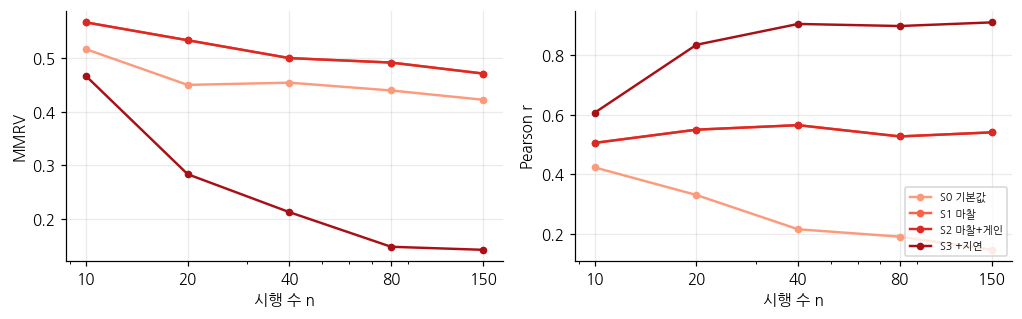

In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.0))
for k, s in enumerate(labels):
    col = plt.cm.Reds(.35 + .17 * k)
    a1.plot(ns, [rows[i][k][0] for i in range(len(ns))], "o-",
            color=col, lw=1.6, ms=4, label=s)
    a2.plot(ns, [rows[i][k][1] for i in range(len(ns))], "o-",
            color=col, lw=1.6, ms=4, label=s)
a1.set_xlabel("시행 수 n")
a1.set_ylabel("MMRV")
a2.set_xlabel("시행 수 n")
a2.set_ylabel("Pearson r")
for a in (a1, a2):
    a.set_xscale("log")
    a.set_xticks(ns)
    a.set_xticklabels([str(v) for v in ns])
    a.xaxis.set_minor_formatter(plt.NullFormatter())
a2.legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

## 완벽히 맞춘 시뮬도 1이 되지 않는다

마지막으로 상한을 잰다. 실기와 **파라미터가 완전히 같은** 시뮬을 세우되 시드만 다르게 준다. 물리도 잡음도 지연도 전부 같으니 남는 차이는 통계 잡음뿐이다.

이 값이 이 실험 설계에서 도달 가능한 상한이다. 어떤 시스템 식별도 이보다 잘할 수 없다.

In [14]:
oracle = run(**REAL_CFG, n=N, seed0=10_000)
ov = np.array([oracle[k].mean() for k in NAMES])
print(f"상한 (같은 파라미터, 다른 시드)   "
      f"MMRV {mmrv(rv, ov):.3f} · r {pearson(rv, ov):.3f}")
print(f"가장 좋은 시뮬 {best_m:<14}   "
      f"MMRV {scores[best_m][0]:.3f} · r {scores[best_m][1]:.3f}")
print()
print(pad("정책", 16) + pad("실기", 9, True) + pad("상한", 9, True))
for k in NAMES:
    print(pad(k, 16) + pad(f"{real[k].mean():.3f}", 9, True)
          + pad(f"{oracle[k].mean():.3f}", 9, True))

상한 (같은 파라미터, 다른 시드)   MMRV 0.007 · r 0.997
가장 좋은 시뮬 S3 +지연           MMRV 0.142 · r 0.910

정책                 실기     상한
직진                0.693    0.673
살살                0.327    0.320
밀고 물러나기       0.507    0.460
돌진-코스트         0.060    0.033
빠른 서보           0.033    0.020
정밀 정렬           0.673    0.700


## 정리

이 노트북에서 만든 것은 자 두 개와 그 자를 쓰는 습관이다.

**MMRV는 순위를, Pearson r은 값을 본다.** 시뮬을 정책 선택에 쓴다면 MMRV를 봐야 한다. 성공률이 전부 어긋나 있어도 순위만 맞으면 시뮬은 제 일을 한 것이고, 성공률이 비슷해도 1등과 꼴찌가 뒤바뀌면 그 시뮬은 쓸모가 없다.

**포화된 시뮬은 아무것도 말해 주지 않는다.** 잡음도 지연도 없는 시뮬에서는 여러 정책이 나란히 1.0을 받는다. 그 상태에서는 순위 정보 자체가 없다. 시뮬을 쉽게 만들면 평가가 쉬워지는 것이 아니라 평가가 **불가능**해진다.

**물리를 더 정확히 맞추는 것이 언제나 이득은 아니다.** 이 실험에서 마찰을 실기 값으로 맞춘 S1은 아무것도 안 맞춘 S0보다 MMRV가 오히려 나빴다. 마찰을 맞추자 시뮬이 쉬워져 다섯 정책이 나란히 천장에 붙었고, 그 바람에 순위가 통째로 사라졌기 때문이다. 반면 지연 하나를 넣은 S3은 MMRV를 3분의 1로 떨어뜨렸다. **어느 갭을 메울지가 얼마나 정밀하게 메울지보다 먼저다.**

**지표에도 신뢰구간이 있다.** 150판으로 잰 값과 20판으로 잰 값은 다른 이야기를 한다. 어느 발표에서 「시뮬과 실기의 상관이 0.9였다」는 문장을 보면 다음에 물을 것은 몇 판을 돌렸는가다.

**상한이 1이 아니다.** 파라미터가 완전히 같아도 시드가 다르면 지표는 1에 못 미친다. 시스템 식별의 목표는 1이 아니라 이 상한이다.

앞으로 나올 모든 노트북은 마지막 셀에서 이 자를 다시 꺼낸다.